In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/titanic-prediction-scc-study-group/titanic_train.csv
/kaggle/input/competitions/titanic-prediction-scc-study-group/sample submission.csv
/kaggle/input/competitions/titanic-prediction-scc-study-group/titanic_test.csv


# EDA（Exploratory Data Analysis）
探索的データ分析

データの参照

In [2]:
import pandas as pd

train_csv = pd.read_csv("/kaggle/input/competitions/titanic-prediction-scc-study-group/titanic_train.csv")
test_csv = pd.read_csv("/kaggle/input/competitions/titanic-prediction-scc-study-group/sample submission.csv")

train_csv.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Survived
0,693,3,"Lam, Mr. Ali",male,NaN,0,0,1601,56.4958,NaN,S,1
1,482,2,"Frost, Mr. Anthony Wood ""Archie""",male,NaN,0,0,239854,0.0000,NaN,S,0
2,528,1,"Farthing, Mr. John",male,NaN,0,0,PC 17483,221.7792,C95,S,0
3,856,3,"Aks, Mrs. Sam (Leah Rosen)",female,18.0,0,1,392091,9.3500,NaN,S,1
4,802,2,"Collyer, Mrs. Harvey (Charlotte Annie Tate)",female,31.0,1,1,C.A. 31921,26.2500,NaN,S,1


# 目的変数”Survived"の割合

In [3]:
Surv_sum = train_csv.Survived.sum()
Surv_sum_ratio = Surv_sum / len(train_csv)
print(f"{Surv_sum_ratio:.3}")

0.383


実際に生存した人間の数は、およそ38%

# それぞれの特徴量の欠損数

In [4]:
train_csv.info()
print()
print(train_csv[["Age","Cabin"]].isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 712 entries, 0 to 711
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  712 non-null    int64  
 1   Pclass       712 non-null    int64  
 2   Name         712 non-null    object 
 3   Sex          712 non-null    object 
 4   Age          575 non-null    float64
 5   SibSp        712 non-null    int64  
 6   Parch        712 non-null    int64  
 7   Ticket       712 non-null    object 
 8   Fare         712 non-null    float64
 9   Cabin        160 non-null    object 
 10  Embarked     710 non-null    object 
 11  Survived     712 non-null    int64  
dtypes: float64(2), int64(5), object(5)
memory usage: 66.9+ KB

Age      137
Cabin    552
dtype: int64


"Age","Caabin"の2つの特徴量が、欠損が多いことがわかる。
それぞれ137個と、552個の欠損あり。

・float,int型　→　7つ

・object型　→　5つ

# 低カーディナリティ特徴量

ここで、低カーディナリティであれば、そのuniqueごとの目的変数に対する相関が比較的容易に見られる可能性があるので、
低カーディナリティ列における生存率を調べて、どの程度の相関があるかを見ていく。

In [5]:
train_csv.nunique()

PassengerId    712
Pclass           3
Name           712
Sex              2
Age             85
SibSp            7
Parch            7
Ticket         571
Fare           226
Cabin          127
Embarked         3
Survived         2
dtype: int64

低カーディナリティに該当する、”Pclass(チケットのクラス/客室階級)"、”Sex(性別）"、”Embarked(出港地)の3つについて、それぞれ見ていく。

それぞれの特徴量でunique値ごとにグループ分けを行い、そのuniqueごとの生存率を見てみる。

In [6]:
low_car = ["Pclass","Sex","Embarked"]

for x in low_car:
    low_car_ratio = train_csv.groupby(x)["Survived"].mean()*100
    print("各ユニーク値における生存率")
    print(low_car_ratio.apply(lambda v : f"{v:.2f}%"))
    print()


各ユニーク値における生存率
Pclass
1    64.91%
2    44.67%
3    24.30%
Name: Survived, dtype: object

各ユニーク値における生存率
Sex
female    74.31%
male      18.52%
Name: Survived, dtype: object

各ユニーク値における生存率
Embarked
C    56.12%
Q    43.64%
S    32.75%
Name: Survived, dtype: object



>"Pclass"においては、1のuniqueの生存率が3に対して実に3倍
>”Sex"においては、femaleのuniqueの生存率がmaleの実に4倍
>”Embarked"においては、Cのuniqueの生存率がSの約1.8倍

全体の生存率は先ほどの通り、38%だったのに対し、"Pclass"の「1」に該当するものでは生存率が全体に比べて1.8倍ほど高く、また、”Sex"の「Female」に該当するものは全体に比べて、約2倍ほど生存率が高くなっている。

この2つの突出している”Pclass"と”Sex"は、目的変数に対して強い相関を持っている可能性が高い。

# "Pclass"と"Sex"特徴量の組み合わせ

"Sex"と”Pcalss"の組み合わせによって分けたそれぞれのuniqueにおける生存率を見ていく

In [7]:
train_csv["Sex_Pclass"] = train_csv["Sex"] + "_" + train_csv["Pclass"].astype(str)
print(train_csv.groupby("Sex_Pclass")["Survived"].mean()*100)


Sex_Pclass
female_1    97.468354
female_2    91.379310
female_3    50.000000
male_1      36.956522
male_2      15.217391
male_3      13.454545
Name: Survived, dtype: float64


/tmp/ipykernel_16/4252135318.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_plot,x="Sex_Pclass",y="Survived",palette="viridis")


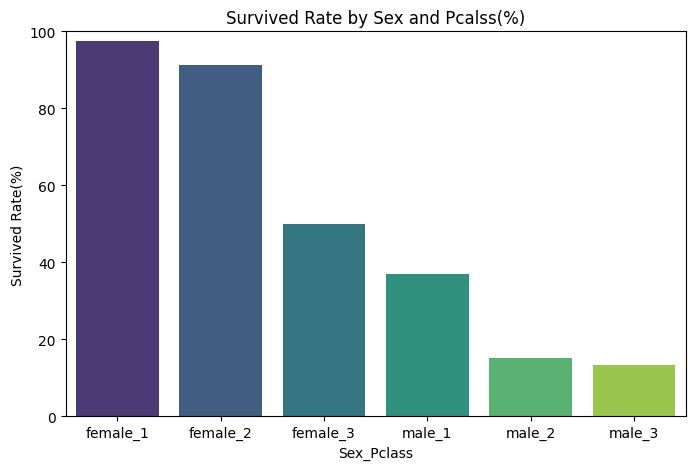

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

#グラフにしやすいようにreset_index()、大きい順に並び替え
df_plot = train_csv.groupby("Sex_Pclass")["Survived"].mean().reset_index()
df_plot["Survived"] = df_plot["Survived"]*100
df_plot = df_plot.sort_values(by="Survived",ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(data=df_plot,x="Sex_Pclass",y="Survived",palette="viridis")

plt.title("Survived Rate by Sex and Pcalss(%)")
plt.xlabel("Sex_Pclass")
plt.ylabel("Survived Rate(%)")
plt.ylim(0,100)
plt.show()

女性においては、1,2階級の客室では生存率が90%以上と顕著。

男性においては、1階級の客室では、ほかに比べて2倍以上の生存率となっている。

よって、この”Sex_Pclass"特徴量は、予測に使えそうであることがわかる。

# 数値列
"Age","SibSp","Parch","Fare"

”Fare"によって、救助の優先順位や、扱いが変わることにより、”Survived”の結果に相関を持ち得ることは容易に想像できる。

In [9]:
train_csv["Fare"].describe()

count    712.000000
mean      31.819826
std       48.059104
min        0.000000
25%        7.895800
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64

ここで、中央値が14.45であるのに対し、maxは512.33となっている。つまり、規定価格とはずいぶんかけ離れた料金で船に乗っている乗客がいることを表している。

これでは、適切な”Fare"と”Survived"の関係性を見ることが難しくなる。よって、対数変換を行う。

数値を log(値) に変換して、

・分布の歪み（右に長い分布）を整える

・外れ値の影響を弱める

In [10]:
import numpy as np

train_csv["logFare"] = np.log1p(train_csv["Fare"])
train_csv.logFare.head()

0    4.051712
1    0.000000
2    5.406181
3    2.336987
4    3.305054
Name: logFare, dtype: float64

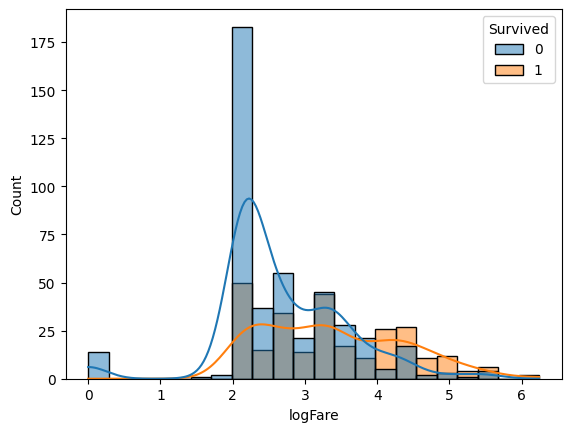

In [11]:
sns.histplot(x=train_csv["logFare"],hue=train_csv["Survived"],kde=True)
plt.show()

このグラフからわかるように、"logFare"の右側、すなわちFareの値が大きくなると、生存者の方が多くなっていることがわかる。

つまり、"Fare"は何かしらの影響を"Survived"に与えていることが直感的な説明からではなく、実際の図から示された。

●続いて、"SibSp","Parch"の2つを見ていく。

これはそれぞれ、同乗している兄弟、配偶者の数と

同乗している親、子供の数を表している。


In [12]:
train_csv.groupby("SibSp")["Survived"].mean()

#sns.histplot(x=train_csv["SibSp"],hue=train_csv["Survived"],kde=True)
#plt.show()

SibSp
0    0.344130
1    0.536585
2    0.523810
3    0.100000
4    0.200000
5    0.000000
8    0.000000
Name: Survived, dtype: float64

In [13]:
train_csv.groupby("Parch")["Survived"].mean()

Parch
0    0.341328
1    0.542553
2    0.540984
3    0.600000
4    0.000000
5    0.200000
6    0.000000
Name: Survived, dtype: float64

これらからわかることは、兄弟や配偶者の数、ないしは親子の数が1-3人の時は生存率が上昇しており、0人、もしくは4人以上の時は生存率が38%よりも低くなっている。特に大家族の場合は、生存率が極端に低下していることがわかる。

”Parch"、”SibSp"はどちらも似た内容の特徴量であり、同じ家族という1組のグループを表している。これはTitanicの自己の際に、足枷ともなるし、また手助けともなりえる。

これらの情報を別個として扱うよりも、先ほどのunique数による生存率の変化の仕方からもわかるように、足し合わせた”家族”としての情報とみても良いだろう。

In [14]:
train_csv["Family"] = train_csv[["Parch","SibSp"]].sum(axis=1)
train_csv.groupby("Family")["Survived"].mean()

Family
0     0.299539
1     0.550388
2     0.623377
3     0.727273
4     0.214286
5     0.062500
6     0.363636
7     0.000000
10    0.000000
Name: Survived, dtype: float64

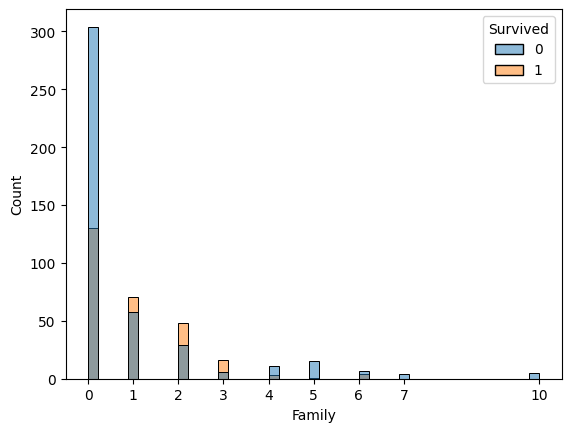

In [15]:
sns.histplot(x=train_csv["Family"],hue=train_csv["Survived"])
#plt.xticks(sorted(train_csv["Family"].unique()))
plt.xticks(train_csv["Family"].unique())
plt.show()

このことから次のことがわかる。

>0(独り身)：生存率は低い
>
>1-3(中規模家族)：生存率が高い
>
>4-10(大規模家族)：生存率は低い
>
よって、”Family”列は、数値の大きさによってグループ分けをした方が、予測への影響を考慮すると得策である。

”Family”の数によって

0(独り身)：alone

1-3(中規模家族)：basic

4-10(大規模家族)：large

にグループ分けをした特徴量”len_Fam"を作る。

In [16]:
def Fam_change(df):
    return df.map(lambda x:
                 "alone" if x==0 else
                 "basic" if 1<=x<=3 else
                 "large")

train_csv["len_Fam"] = train_csv["Family"].transform(Fam_change)
train_csv.groupby("len_Fam")["Survived"].mean()
        

len_Fam
alone    0.299539
basic    0.592105
large    0.160000
Name: Survived, dtype: float64

# まとめ

新しく追加する特徴量として、”Sex_Pclass"、"logFare"、"len_Fam"の3つを考える。